# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
import os
import tqdm
import numpy
import numpy as np
import torch
import pandas
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2

In [2]:
# Можно использовать, но балл за соответствующие задания будет снижен.
# import pytorch_metric_learning.distances
# import pytorch_metric_learning.samplers
# import pytorch_metric_learning.losses

In [3]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [4]:
# хочу узнать реальные mean, std

from torch.utils.data import DataLoader
from torchvision import transforms as T

transform = T.Compose(
    [
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

calc_ds = torchvision.datasets.ImageFolder("data/training", transform=transform)
loader = DataLoader(calc_ds, batch_size=64, shuffle=False, num_workers=4)
n, ch_sum, ch_sq_sum = 0, torch.zeros(3), torch.zeros(3)

for x, _ in loader:
    b = x.size(0)
    x = x.view(b, 3, -1)
    ch_sum += x.sum(dim=[0, 2])
    ch_sq_sum += (x**2).sum(dim=[0, 2])
    n += b * x.size(2)

mean = ch_sum / n
std = (ch_sq_sum / n - mean**2).sqrt()
print("mean =", mean.tolist(), "std =", std.tolist()) # как можно увидеть, сильно разнятся от списка из 0.5

mean = [-0.14022941887378693, -0.25058332085609436, -0.33512794971466064] std = [0.5941681861877441, 0.5442644357681274, 0.5308489203453064]


In [5]:
from torchvision import transforms as T

train_tf = T.Compose([
    T.Resize(192),
    T.RandomResizedCrop(160, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1, 0.1, 0.05, 0.02),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),
    # используем полученные mean, std
    T.Normalize(mean, std),
])

test_tf = T.Compose([
    T.Resize((160,160)),
    T.ToTensor(),
    T.Normalize(mean, std),
])

train_ds = torchvision.datasets.ImageFolder("data/training", transform=train_tf)
test_ds = torchvision.datasets.ImageFolder("data/testing", transform=test_tf)

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    # если в дальнейшем не будет запускаться, есть смысл уменьшить количество воркеров
    # я запускал на 3080 12gb, и у меня VS Code вылетал иногда =)
    num_workers=12,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    test_ds, batch_size=128, shuffle=False, num_workers=12, pin_memory=True
)

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

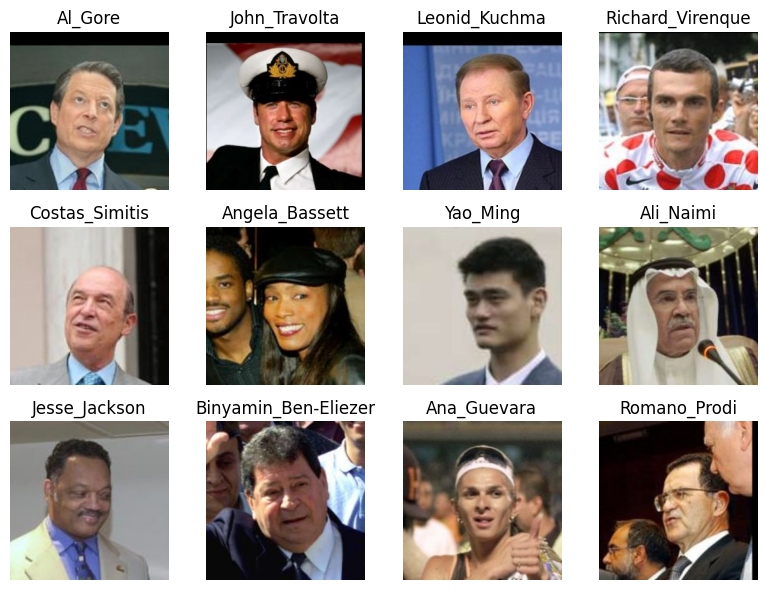

In [7]:
# Хочется посмотреть на стоковые снимки
show_transform = T.Compose(
    [
        T.ToTensor(),
    ]
)
show_ds = torchvision.datasets.ImageFolder("data/training", transform=show_transform)
show_loader = DataLoader(
    show_ds,
    batch_size=128,
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    drop_last=True,
)

images, labels = next(iter(show_loader))
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax, img, lbl in zip(axes.ravel(), images, labels):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(train_ds.classes[int(lbl)])
    ax.axis("off")

plt.tight_layout()
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

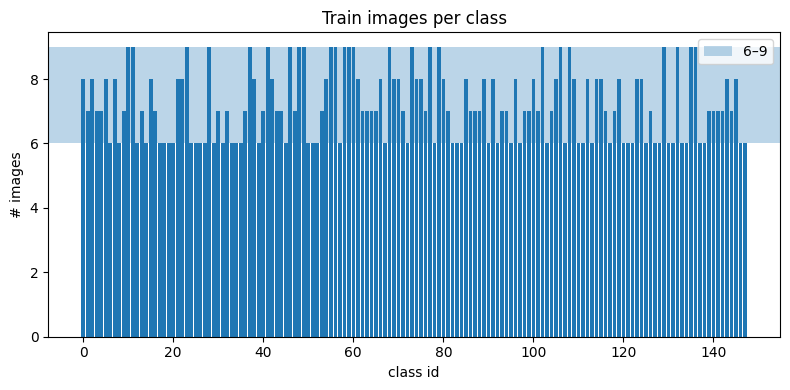

Вне диапазона [6,9]: 0 классов


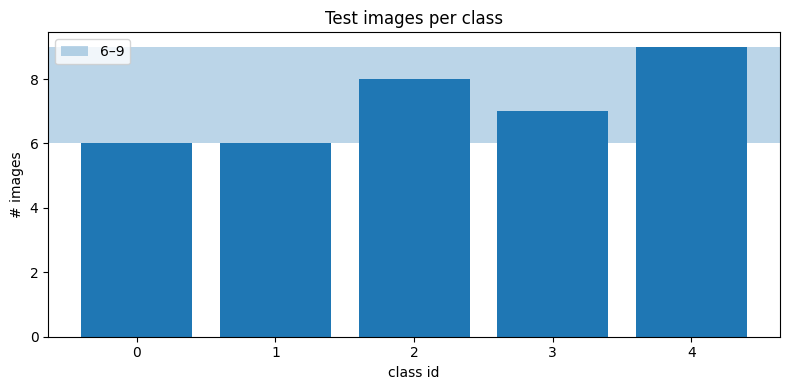

Вне диапазона [6,9]: 0 классов


In [8]:
from collections import Counter

def show_class_distribtion(targets, ds_name = "", expected_min=6, expected_max=9):
    cnt = Counter(targets)
    classes = sorted(cnt.keys())
    freqs = [cnt[c] for c in classes]

    plt.figure(figsize=(8, 4))
    plt.bar(classes, freqs)
    plt.axhspan(expected_min, expected_max, alpha=0.3, label=f"{expected_min}–{expected_max}")
    plt.xlabel("class id"); plt.ylabel("# images"); plt.title(f"{ds_name} images per class")
    plt.legend(); plt.tight_layout(); plt.show()

    bad = [c for c,f in cnt.items() if not (expected_min <= f <= expected_max)]
    print(f"Вне диапазона [{expected_min},{expected_max}]: {len(bad)} классов")

show_class_distribtion(train_ds.targets, "Train")
show_class_distribtion(test_ds.targets, "Test")

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [9]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)
    
    def _idx2(self, idx):
        return idx // len(self.dataset)
    
    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

In [10]:
train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 1835804.79it/s]


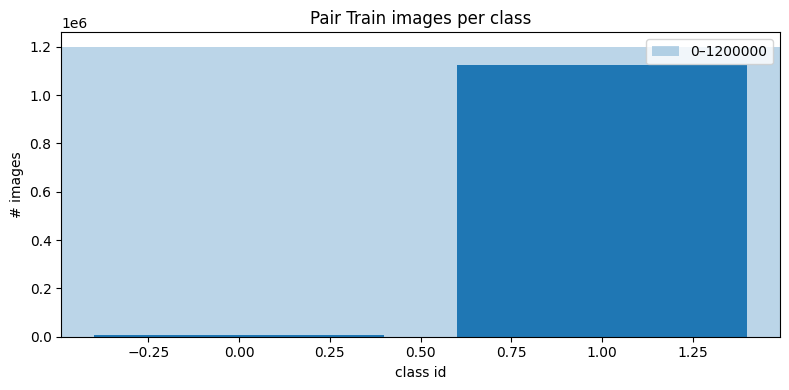

Вне диапазона [0,1200000]: 0 классов


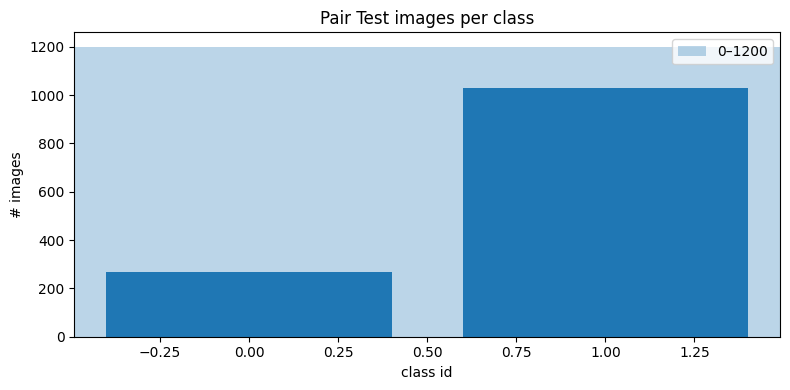

Вне диапазона [0,1200]: 0 классов


In [11]:
show_class_distribtion(train_pairs.targets, "Pair Train", 0, 12 * 100 * 1000)
show_class_distribtion(test_pairs.targets, "Pair Test", 0, 12 * 100)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [ ]:
from torch.utils.data import Sampler

class PairSampler(Sampler):

    def __init__(self, targets, base_len, batch_size, pos_fraction=0.5):
        seed = 42

        self.batch_size = batch_size
        self.k_pos = int(round(batch_size * pos_fraction))
        self.k_neg = batch_size - self.k_pos
        self.rng = np.random.default_rng(seed)

        targets = np.array(targets)
        idx_all = np.arange(len(targets))

        pos = idx_all[(targets == 1)]
        neg = idx_all[(targets == 0)]

        # вырежем диагонали
        i1 = idx_all % base_len
        i2 = idx_all // base_len
        mask_offdiag = i1 != i2

        pos = idx_all[(targets == 1) & mask_offdiag]
        neg = idx_all[(targets == 0) & mask_offdiag]

        num_batches = min(len(pos) // self.k_pos, len(neg) // self.k_neg)

        order = []
        pi = ni = 0
        for _ in range(num_batches):
            if pi + self.k_pos > len(pos):
                pos = self.rng.permutation(pos)
                pi = 0
            if ni + self.k_neg > len(neg):
                neg = self.rng.permutation(neg)
                ni = 0

            batch = np.concatenate([pos[pi:pi+self.k_pos], neg[ni:ni+self.k_neg]])
            pi += self.k_pos
            ni += self.k_neg

            self.rng.shuffle(batch)
            order.extend(batch.tolist())

        self._order = order

    def __iter__(self):
        for idx in self._order:
            yield idx

    def __len__(self):
        return len(self._order)

In [13]:
TASK2_BATCH_SIZE = 64
train_pairs_sampler = PairSampler(train_pairs.targets, len(train_ds), batch_size=TASK2_BATCH_SIZE)


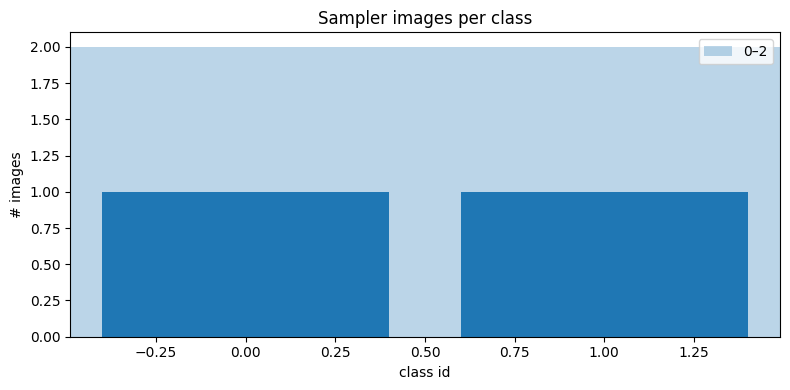

Вне диапазона [0,2]: 0 классов


In [14]:
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, sampler = train_pairs_sampler, batch_size=TASK2_BATCH_SIZE)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = TASK2_BATCH_SIZE, shuffle = False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2], "Sampler", 0, 2)

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class ClassificationNet(torch.nn.Module):

    # class Encoder(nn.Module):

    #     def __init__(self):
    #         super().__init__()
    #         self.features = nn.Sequential(
    #             nn.Conv2d(3, 48, 3, padding=1),
    #             nn.BatchNorm2d(48),
    #             nn.ReLU(),
    #             nn.Conv2d(48, 48, 3, padding=1),
    #             nn.BatchNorm2d(48),
    #             nn.ReLU(),
    #             nn.MaxPool2d(2),
    #             nn.Conv2d(48, 96, 3, padding=1),
    #             nn.BatchNorm2d(96),
    #             nn.ReLU(),
    #             nn.Conv2d(96, 96, 3, padding=1),
    #             nn.BatchNorm2d(96),
    #             nn.ReLU(),
    #             nn.MaxPool2d(2),
    #             nn.Conv2d(96, 192, 3, padding=1),
    #             nn.BatchNorm2d(192),
    #             nn.ReLU(),
    #             nn.AdaptiveAvgPool2d((1, 1)),
    #         )
    #         self.proj = nn.Linear(192, 192)

    #     def forward(self, x):
    #         x = self.features(x).flatten(1)
    #         x = self.proj(x)
    #         return F.normalize(x, p=2, dim=1)

    class ClassificationEncoder(nn.Module):
        
        def __init__(self, emb_dim=192):
            super().__init__()
            features = models.resnet18(weights=None)
            in_dim = features.fc.in_features
            features.fc = nn.Identity()
            self.features = features
            self.head = nn.Linear(in_dim, emb_dim)

        def forward(self, x):
            z = self.features(x)
            e = self.head(z)
            return e

    def __init__(self):
        super().__init__()
        self.enc = ClassificationNet.ClassificationEncoder()
        self.head = nn.Sequential(
            nn.Linear(192 * 3, 192),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(192, 1),
        )

    def forward(self, image1, image2):
        e1 = self.enc(image1)
        e2 = self.enc(image2)
        feats = torch.cat([torch.abs(e1 - e2), e1 * e2, (e1 - e2) ** 2], dim=1)
        logits = self.head(feats).squeeze(1)
        return logits


# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (
    TASK2_BATCH_SIZE,
)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [16]:
# копипаста из семинара

def plot_history_epoch(train_history, val_history, title="loss"):
    epochs = np.arange(1, len(train_history) + 1)
    plt.figure()
    plt.title(title)
    plt.plot(epochs, train_history, label="train")
    plt.plot(epochs, val_history,   label="val", marker="o")
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend(loc="best")
    plt.show()


def plot_auc(train_auc, val_auc):
    plot_history_epoch(train_auc, val_auc, title="AUC-ROC")


def plot_time(time_log):
    epochs = np.arange(1, len(time_log) + 1)
    plt.figure()
    plt.title("Epoch time (seconds)")
    plt.plot(epochs, time_log, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Time, sec")
    plt.grid(True)
    plt.show()

In [17]:
import time
from tqdm.auto import tqdm as tqdm_auto
from sklearn.metrics import roc_auc_score
from IPython.display import clear_output

# здесь тоже взял пайплайн семинара

def train(model, criterion, optimizer, train_dataloader, val_dataloader, n_epochs, scheduler = None):
    train_loss_log, train_auc_log, val_loss_log, val_auc_log = [], [], [], []
    epoch_time_log = []

    for epoch in range(n_epochs):
        epoch_start = time.time()

        model.train()
        train_losses = []
        y_true_all, y_score_all = [], []

        for img1, img2, labels in tqdm_auto(
            train_dataloader, desc=f"Training, epoch {epoch}", leave=False
        ):
            img1, img2 = img1.to(device), img2.to(device)
            labels = labels.float().to(device)

            logits = model(img1, img2)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_losses.append(loss.detach().cpu().item())
            y_true_all.append(labels.detach().cpu())
            y_score_all.append(torch.sigmoid(logits.detach().cpu()))

        y_true = torch.cat(y_true_all).numpy()
        y_score = torch.cat(y_score_all).numpy()

        train_auc = float(roc_auc_score(y_true, y_score))

        model.eval()
        val_losses = []
        y_true_all, y_score_all = [], []

        with torch.no_grad():
            for img1, img2, labels in tqdm_auto(
                val_dataloader, desc=f"Validating, epoch {epoch}", leave=False
            ):
                img1, img2 = img1.to(device), img2.to(device)
                labels = labels.float().to(device)

                logits = model(img1, img2)
                loss = criterion(logits, labels)
                val_losses.append(loss.detach().cpu().item())

                y_true_all.append(labels.detach().cpu())
                y_score_all.append(torch.sigmoid(logits.detach().cpu()))

        y_true = torch.cat(y_true_all).numpy()
        y_score = torch.cat(y_score_all).numpy()
        val_auc = float(roc_auc_score(y_true, y_score))

        if scheduler is not None:
            scheduler.step()

        train_loss_log.append(np.mean(train_losses))
        val_loss_log.append(np.mean(val_losses))
        train_auc_log.append(train_auc)
        val_auc_log.append(val_auc)

        epoch_time = time.time() - epoch_start
        epoch_time_log.append(epoch_time)

        clear_output()
        plot_history_epoch(train_loss_log, val_loss_log, "loss")
        plot_auc(train_auc_log, val_auc_log)
        plot_time(epoch_time_log)

        print(f"Epoch {epoch+1}/{n_epochs}")
        print(f"Train loss: {np.mean(train_losses):.4f} | Train AUC: {train_auc:.4f}")
        print(f"Val   loss: {np.mean(val_losses):.4f} | Val   AUC: {val_auc:.4f}")
        print(f"Epoch time: {epoch_time:.2f} sec")

/home/xarm86/hse/iad-deep-learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# перед всей этой суетой хочется заиметь val_loader

from torch.utils.data import Subset


def split_by_classes(labels, val_ratio=0.02):
    rng = np.random.default_rng(42)
    classes = np.unique(labels)
    rng.shuffle(classes)
    n_val = max(1, int(round(len(classes) * val_ratio)))
    val_set = set(classes[:n_val])

    idx_all = np.arange(len(labels))
    val_idx = idx_all[np.isin(labels, list(val_set))].tolist()
    train_idx = idx_all[~np.isin(labels, list(val_set))].tolist()
    return train_idx, val_idx


train_ds_all = torchvision.datasets.ImageFolder("data/training", transform=train_tf)
val_ds_all = torchvision.datasets.ImageFolder("data/training", transform=test_tf)
labels = train_ds_all.targets

train_idx, val_idx = split_by_classes(labels)

train_ds = Subset(train_ds_all, train_idx)
train_ds.targets = [labels[i] for i in train_idx]

val_ds = Subset(val_ds_all, val_idx)
val_ds.targets = [labels[i] for i in val_idx]

train_pairs = PairDataset(train_ds)
train_pairs_sampler = PairSampler(train_pairs.targets, len(train_ds), batch_size=TASK2_BATCH_SIZE)
train_pairs_loader = torch.utils.data.DataLoader(
    train_pairs, sampler=train_pairs_sampler, batch_size=TASK2_BATCH_SIZE, num_workers=10, pin_memory=True
)

val_pairs = PairDataset(val_ds)
val_pairs_loader = torch.utils.data.DataLoader(
    val_pairs, batch_size=64, shuffle=False, num_workers=10
)

test_pairs = PairDataset(test_ds)
test_pairs_loader = torch.utils.data.DataLoader(
    test_pairs, batch_size=64, shuffle=False, num_workers=10
)

  0%|          | 0/1092025 [00:00<?, ?it/s]

100%|██████████| 1296/1296 [00:00<00:00, 1772934.76it/s]


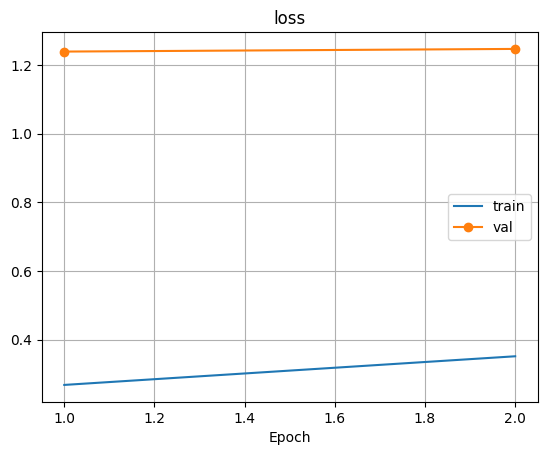

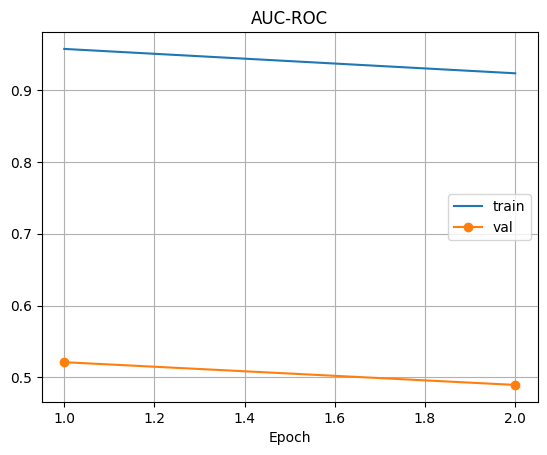

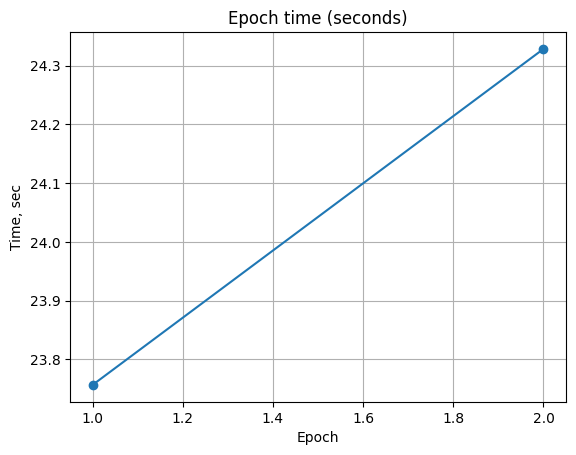

Epoch 2/10
Train loss: 0.3520 | Train AUC: 0.9238
Val   loss: 1.2462 | Val   AUC: 0.4893
Epoch time: 24.33 sec


KeyboardInterrupt: 

In [31]:
NUM_EPOCH = 10

model = ClassificationNet().to(device)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCH)

set_random_seed()
train(model, criterion, optimizer, train_pairs_loader, val_pairs_loader, NUM_EPOCH, scheduler)

In [28]:
import tqdm

def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

score = get_auc_roc(model)
print(f"AUC-ROC: {score}")
get_score(score)

  0%|          | 0/21 [00:01<?, ?it/s]


TypeError: Encoder.forward() takes 2 positional arguments but 3 were given

##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

1) обучил простую модельку с энкодером -> эмбеддинг -> |e1 − e2| и e1 * e2 в качестве признаков
2) вышел AUC ~0.6
3) добавил аугментаций, шедулер, нейронов в модельку, добавил третий признак - (e1 - e2) ** 2
4) очень много ждал
5) получил AUC=0.8394

Проблемы бин классификации:
1) постановка задачи - мало данных для задачи бин классификации 
2) функция потерь оптимизирует классификацию отдельных пар, но не заставляет эмбеддинги разных людей быть далеко друг от друга
3) несбалансированность данных (очень много разных пар). модель быстро запоминает, что скорее люди отличны, чем схожи.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [21]:
import torch
import torch.nn as nn


class TripletLoss(nn.Module):

    def __init__(self, margin: float = 0.25):
        super().__init__()
        self.margin = margin

    def forward(self, emds: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:

        len_0 = emds.size(0)
        labels = labels.to(device=emds.device)
        losses = []
        for i in range(len_0):
            for j in range(len_0):
                if j == i:
                    continue
                if labels[j] != labels[i]:
                    continue
                # ||f(A) - f(P)||
                d_ap = torch.norm(emds[i] - emds[j], p=2)
                for k in range(len_0):
                    if labels[k] == labels[i]:
                        continue
                    # ||f(A) - f(N)||
                    d_an = torch.norm(emds[i] - emds[k], p=2)
                    losses.append(torch.relu(d_ap - d_an + self.margin))

        assert(len(losses) != 0)

        return torch.stack(losses).mean()

In [22]:
criterion = TripletLoss(margin=0.25)
# Вы можете использовать этот ассерт в качестве теста

emds = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
print(criterion(emds, labels) - 2.6775)
assert (criterion(emds, labels) - 2.6775) < 1e-4

tensor(-7.3910e-06)


##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [23]:
class PKSampler(Sampler):

    def __init__(self, labels, P: int, K: int):
        seed = 42

        self.labels = np.asarray(labels)
        self.P = int(P)
        self.K = int(K)
        self.rng = np.random.default_rng(seed)

        self.by_class = {}
        for idx, y in enumerate(self.labels):
            self.by_class.setdefault(int(y), []).append(idx)

        self.classes = [c for c, idxs in self.by_class.items()]
        for c in self.classes:
            self.by_class[c] = np.array(self.by_class[c], dtype=int)
            self.rng.shuffle(self.by_class[c])

        print(f"PKSampler: Len classes {len(self.classes)}")

        self.ptrs = {c: 0 for c in self.classes}

        total = sum(len(self.by_class[c]) for c in self.classes)
        self.batch_size = self.P * self.K
        self._num_batches = total // self.batch_size

        order = []
        for _ in range(self._num_batches):
            chosen = list(self.classes)
            self.rng.shuffle(chosen)
            chosen = chosen[: self.P]

            batch = []
            for c in chosen:
                start = self.ptrs[c]
                end = start + self.K
                if end > len(self.by_class[c]):
                    self.rng.shuffle(self.by_class[c])
                    start = 0
                    end = self.K
                batch.extend(self.by_class[c][start:end].tolist())
                self.ptrs[c] = end

            batch = np.array(batch, dtype=int)
            self.rng.shuffle(batch)
            order.extend(batch.tolist())

        self._order = order

    def __iter__(self):
        for idx in self._order:
            yield idx

    def __len__(self):
        return len(self._order)

In [24]:
import time
from tqdm.auto import tqdm as tqdm_auto
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

def pairs_for_auc(embeddings: torch.Tensor, labels: torch.Tensor):
    with torch.no_grad():
        emb = F.normalize(embeddings, dim=1)
        sim = emb @ emb.t()
        B = sim.size(0)
        iu = torch.triu_indices(B, B, offset=1)
        scores = sim[iu[0], iu[1]]
        y_true = (labels[iu[0]] == labels[iu[1]]).float()
        return y_true.cpu().numpy(), scores.cpu().numpy()

def train_triplet(
    model, criterion, optimizer, train_dataloader, val_dataloader,
    n_epochs, scheduler=None
):
    train_loss_log, train_auc_log, val_loss_log, val_auc_log = [], [], [], []
    epoch_time_log = []

    for epoch in range(n_epochs):
        epoch_start = time.time()

        model.train()
        train_losses = []
        y_true_all, y_score_all = [], []

        for images, labels in tqdm_auto(train_dataloader, desc=f"Training, epoch {epoch}", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            emb = model(images)
            loss = criterion(emb, labels)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_losses.append(loss.detach().cpu().item())

            y_t, y_s = pairs_for_auc(emb.detach(), labels)
            y_true_all.append(y_t)
            y_score_all.append(y_s)

        y_true = np.concatenate(y_true_all)
        y_score = np.concatenate(y_score_all)
        train_auc = float(roc_auc_score(y_true, y_score))

        model.eval()
        val_losses = []
        y_true_all, y_score_all = [], []

        with torch.no_grad():
            for images, labels in tqdm_auto(val_dataloader, desc=f"Validating, epoch {epoch}", leave=False):
                images = images.to(device)
                labels = labels.to(device)

                emb = model(images)
                loss = criterion(emb, labels)
                val_losses.append(loss.detach().cpu().item())

                y_t, y_s = pairs_for_auc(emb, labels)
                y_true_all.append(y_t)
                y_score_all.append(y_s)

        y_true = np.concatenate(y_true_all)
        y_score = np.concatenate(y_score_all)
        val_auc = float(roc_auc_score(y_true, y_score))

        if scheduler is not None:
            scheduler.step()

        train_loss_log.append(np.mean(train_losses))
        val_loss_log.append(np.mean(val_losses))
        train_auc_log.append(train_auc)
        val_auc_log.append(val_auc)

        epoch_time = time.time() - epoch_start
        epoch_time_log.append(epoch_time)

        print(f"Epoch {epoch+1}/{n_epochs}")
        print(f"Train loss: {train_loss_log[-1]:.4f} | Train AUC: {train_auc:.4f}")
        print(f"Val   loss: {val_loss_log[-1]:.4f} | Val   AUC: {val_auc:.4f}")
        print(f"Epoch time: {epoch_time:.2f} sec")


In [ ]:
from torchvision import models

class ClassificationEncoder(nn.Module):
    def __init__(self, emb_dim=192):
        super().__init__()
        features = models.resnet18(weights=None)
        in_dim = features.fc.in_features
        features.fc = nn.Identity()
        self.features = features
        self.head = nn.Linear(in_dim, emb_dim)

    def forward(self, x):
        z = self.features(x)
        e = self.head(z)
        return e

In [ ]:
embedding_dim = 192
margin = 0.2
P, K = 3, 3
batch_size = P * K
n_epochs = 40

train_labels = [y for _, y in train_ds]
val_labels = [y for _, y in val_ds]
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=PKSampler(train_labels, P, K),
    num_workers=10,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    sampler=PKSampler(val_labels, P, K),
    num_workers=10, 
    drop_last=True, 
)

model = ClassificationEncoder(embedding_dim).to(device)
criterion = TripletLoss(margin=margin)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

set_random_seed()
train_triplet(
    model, criterion, optimizer, train_loader, val_loader, n_epochs, scheduler
)

PKSampler: Len classes 145
PKSampler: Len classes 3


Epoch 1/40
Train loss: 0.3123 | Train AUC: 0.5698
Val   loss: 0.2427 | Val   AUC: 0.5154
Epoch time: 7.53 sec


Epoch 2/40
Train loss: 0.1539 | Train AUC: 0.6761
Val   loss: 0.1840 | Val   AUC: 0.5895
Epoch time: 7.23 sec


Epoch 3/40
Train loss: 0.1326 | Train AUC: 0.7137
Val   loss: 0.1901 | Val   AUC: 0.5278
Epoch time: 7.15 sec


Epoch 4/40
Train loss: 0.1243 | Train AUC: 0.7309
Val   loss: 0.1706 | Val   AUC: 0.5998
Epoch time: 7.24 sec


...

Epoch 22/40
Train loss: 0.0407 | Train AUC: 0.9009
Val   loss: 0.1379 | Val   AUC: 0.7325
Epoch time: 7.16 sec


Epoch 23/40
Train loss: 0.0327 | Train AUC: 0.9131
Val   loss: 0.0899 | Val   AUC: 0.8261
Epoch time: 7.13 sec


Epoch 24/40
Train loss: 0.0283 | Train AUC: 0.9277
Val   loss: 0.1107 | Val   AUC: 0.7881
Epoch time: 7.13 sec


Epoch 25/40
Train loss: 0.0267 | Train AUC: 0.9386
Val   loss: 0.0914 | Val   AUC: 0.8385
Epoch time: 7.08 sec


KeyboardInterrupt: 

In [ ]:
import tqdm

def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

score = get_auc_roc(model)
print(f"AUC-ROC: {score}")
get_score(score)

100%|██████████| 11/11 [00:01<00:00,  5.86it/s]

AUC-ROC: 0.9339951821300825


2.6799036426016487

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

In [ ]:
# я джеймс бонд со словарем